In [1]:
import os, sys

os.chdir(r"C:\Users\DANGER\Downloads\quality_control_vision")
os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("data/processed/good", exist_ok=True)
os.makedirs("data/processed/defective", exist_ok=True)
sys.path.append('src')

print("OK:", os.getcwd())

OK: C:\Users\DANGER\Downloads\quality_control_vision


In [2]:
from preprocess import prepare_dataset
prepare_dataset(data_dir="data/raw", output_dir="data/processed")

[OK] good → 1225 images traitées
[OK] defective → 504 images traitées


In [3]:
import cv2, os
from pathlib import Path

src = Path("data/raw/good")
dst = Path("data/processed/good")

count = 0
for filename in os.listdir(src):
    if not (filename.endswith(".png") or filename.endswith(".jpg")):
        continue
    img = cv2.imread(str(src / filename))
    if img is None:
        continue
    img  = cv2.resize(img, (224, 224))
    stem = filename.replace(".png","").replace(".jpg","").replace(" ","_")

    for i, aug in enumerate([
        cv2.flip(img, 1),
        cv2.flip(img, 0),
        cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE),
        cv2.rotate(img, cv2.ROTATE_180),
    ]):
        cv2.imwrite(str(dst / f"{stem}_aug{i}.png"), aug)
        count += 1

print(f"Ajoute : {count} images")
print(f"good total : {len(os.listdir(dst))}")
print(f"defective total : {len(os.listdir('data/processed/defective'))}")

Ajoute : 916 images
good total : 1225
defective total : 504


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np, matplotlib.pyplot as plt, seaborn as sns, os

DATA_DIR   = "data/processed"
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

gen = ImageDataGenerator(
    rescale=1./255, rotation_range=20,
    horizontal_flip=True, zoom_range=0.2,
    validation_split=0.2
)
val_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = gen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True
)
val_data = val_gen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False
)

n_def  = len(os.listdir(f"{DATA_DIR}/defective"))
n_good = len(os.listdir(f"{DATA_DIR}/good"))
total  = n_def + n_good
class_weight = {
    train_data.class_indices['defective']: total / (2 * n_def),
    train_data.class_indices['good']:      total / (2 * n_good)
}
print("Classes:", train_data.class_indices)
print("Weights:", class_weight)
print(f"good: {n_good} | defective: {n_def}")

base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

inputs  = tf.keras.Input(shape=(224,224,3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(2, activation='softmax')(x)
model   = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ModelCheckpoint("models/best_mobile.keras", save_best_only=True, monitor='val_accuracy', verbose=1),
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-7, verbose=1)
]

history = model.fit(
    train_data, validation_data=val_data,
    epochs=25, callbacks=callbacks,
    class_weight=class_weight
)

Found 1384 images belonging to 2 classes.
Found 345 images belonging to 2 classes.
Classes: {'defective': 0, 'good': 1}
Weights: {0: 1.7152777777777777, 1: 0.7057142857142857}
good: 1225 | defective: 504
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 899ms/step - accuracy: 0.8487 - loss: 0.3962
Epoch 1: val_accuracy improved from None to 0.95072, saving model to models/best_mobile.keras

Epoch 1: finished saving model to models/best_mobile.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.9249 - loss: 0.2353 - val_accuracy: 0.9507 - val_loss: 0.1065 - learning_rate: 0.0010
Epoch 2/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.9698 - loss: 0.1088
Epoch 2: val_accuracy improved from 0.95072 to 0.96522, saving model to models/best_mobile.keras

Epoch 2: finished saving model to models/best_mobile.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 37s 848ms/step - accuracy: 0.9754 - loss: 0.0952 - val_accuracy: 0.9652 - val_loss: 0.0986 - learn

11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 617ms/step
              precision    recall  f1-score   support

   defective       0.98      0.98      0.98       100
        good       0.99      0.99      0.99       245

    accuracy                           0.99       345
   macro avg       0.99      0.99      0.99       345
weighted avg       0.99      0.99      0.99       345



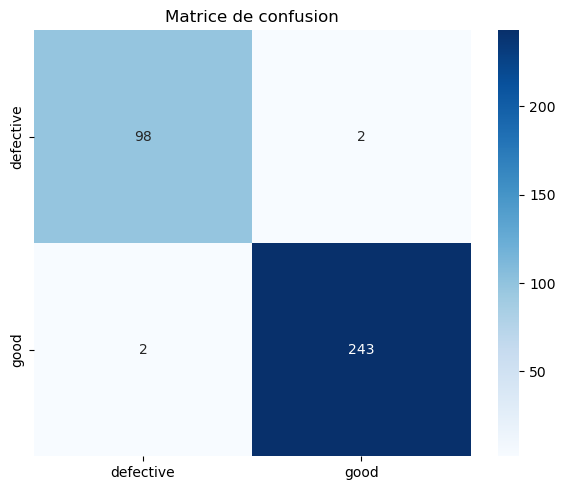

In [6]:
val_data.reset()
preds  = model.predict(val_data)
y_pred = np.argmax(preds, axis=1)
y_true = val_data.classes
labels = list(val_data.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150)
plt.show()

In [7]:
import subprocess
subprocess.Popen(["streamlit", "run", "app.py"])
print("Ouvre http://localhost:8501")

Ouvre http://localhost:8501


In [8]:
gitignore_content = """# Données et modèles (trop lourds pour GitHub)
data/
models/
outputs/
__pycache__/
*.h5
*.keras
venv/
.ipynb_checkpoints/
"""

with open(".gitignore", "w") as f:
    f.write(gitignore_content)

print("✅ .gitignore créé !")

✅ .gitignore créé !


In [9]:
import os
print(os.path.exists(".gitignore"))  # doit afficher True


True
